In [1]:
import tensorflow as tf
from PIL import Image
import numpy as np
from model_fit_evaluate import evaluate_model_on_test_data

Num GPUs Available:  1
GPU is available, using GPU for training.


In [2]:
class Ensemble:
    names = []
    models = []
    preprocess_input = []
    def __init__(self, models_paths: dict, preprocess_functions: list):
        self.preprocess_input = preprocess_functions
        for name, path in models_paths.items():
            self.models.append(tf.keras.models.load_model(path))
            self.names.append(name)
    def count_optimal_thresholds(X_test):
        true_labels = X_test.classes
        thresholds = []
        for i in range(len(self.models)):
            predictions = self.models[i].predict(self.preprocess_input[i](X_test))
            fpr, tpr, thresholds = roc_curve(true_labels, predictions)
            youden_index = tpr - fpr
            optimal_idx = np.argmax(youden_index)
            optimal_threshold = thresholds[optimal_idx]
            thresholds.append(optimal_threshold)
        return np.array(thresholds)
        
    def soft_prediction(self, X_test):
        soft_predictions = []
        for i in range(len(self.models)):
            soft_predictions.append(self.models[i].predict(self.preprocess_input[i](X_test)))
        mean = np.mean(soft_predictions, axis=0)
        return mean, np.array(soft_predictions)

    def hard_voting_prediction(self, X_test):
        hard_predictions = []
        true_labels = X_test.classes
        thresholds = []
        for i in range(len(self.models)):
            pred = self.models[i].predict(self.preprocess_input[i](X_test))
            fpr, tpr, thresholds = roc_curve(true_labels, predictions)
            youden_index = tpr - fpr
            optimal_idx = np.argmax(youden_index)
            optimal_threshold = thresholds[optimal_idx]
            class_labels = np.argmax(pred, axis=1)
            hard_predictions.append(class_labels)
        
        # Голосование большинством
        stacked = np.stack(hard_predictions, axis=1)
        final_predictions = []
        for sample in stacked:
            unique, counts = np.unique(sample, return_counts=True)
            final_predictions.append(unique[np.argmax(counts)])
        
        return np.array(final_predictions), np.array(hard_predictions)

    def median_prediction(self, X_test):
        soft_predictions = []
        for i in range(len(self.models)):
            soft_predictions.append(self.models[i].predict(self.preprocess_input[i](X_test)))
        median_pred = np.median(soft_predictions, axis=0)
        return median_pred, np.array(soft_predictions)
    
    def soft_prediction(self, dir_path: str):
        soft_predictions = []
        score = []
        for i in range(len(self.models)):
            metrics, true_labels, predicions, predicted_labels = evaluate_model_on_test_data(
                self.models[i], 
                dir_path, 
                self.preprocess_input[i], 
                image_size=(224, 224), 
                batch_size=32
            )
            soft_predictions.append(predicions)
            score.append(metrics)
        mean = np.mean(soft_predictions, axis=0)
        return mean, np.array(soft_predictions), np.array(score)

#def 

In [3]:
models_paths = {
    #'EfficientNetB2': '../train_test_models/EfficientNetB2_Deepfake.keras',
    'InceptionV3': '../train_test_v2_balanced/InceptionV3_Deepfake.keras',
    'MobileNetV2': '../train_test_v2_balanced/MobileNetV2_Deepfake.keras',
    'ResNetV2': '../train_test_v2_balanced/ResNetV2_Deepfake.keras',
    'VGG16': '../train_test_v2_balanced/VGG16_Deepfake.keras',
    'Xception': '../train_test_v2_balanced/Xception_Deepfake.keras'
}

preprocess_functions = [
    tf.keras.applications.inception_v3.preprocess_input,
    tf.keras.applications.mobilenet_v2.preprocess_input,
    tf.keras.applications.resnet_v2.preprocess_input,
    tf.keras.applications.vgg16.preprocess_input,
    tf.keras.applications.xception.preprocess_input
]

In [4]:
ens = Ensemble(models_paths, preprocess_functions)

Found 44800 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1400/1400 [==============================] - 980s 697ms/step
[[0]
 [1]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.91      0.21      0.34     34023
        Real       0.27      0.94      0.42     10777

    accuracy                           0.38     44800
   macro avg       0.59      0.57      0.38     44800
weighted avg       0.76      0.38      0.36     44800

Confusion Matrix:
[[ 7036 26987]
 [  675 10102]]


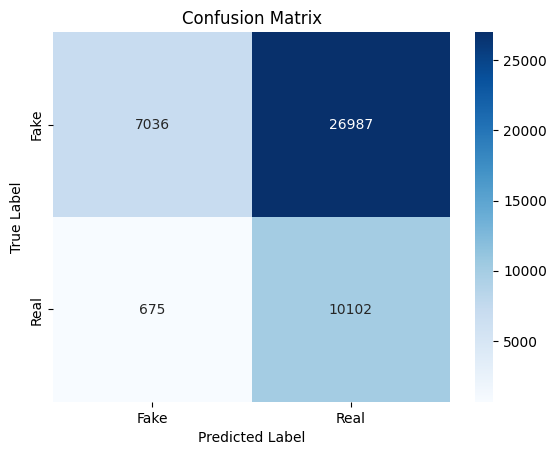

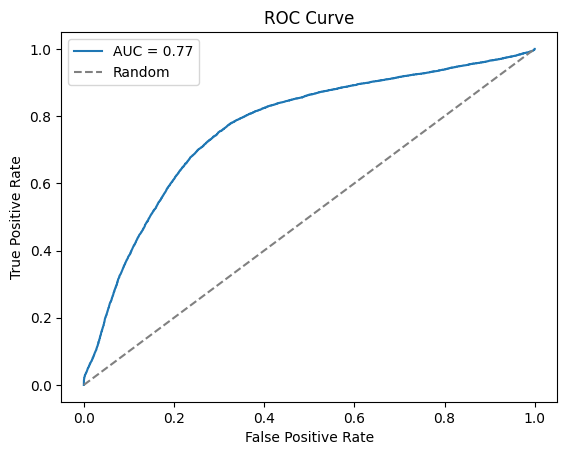

Found 44800 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1400/1400 [==============================] - 167s 118ms/step
[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.46      0.02      0.04     34023
        Real       0.23      0.93      0.37     10777

    accuracy                           0.24     44800
   macro avg       0.35      0.47      0.20     44800
weighted avg       0.41      0.24      0.12     44800

Confusion Matrix:
[[  684 33339]
 [  790  9987]]


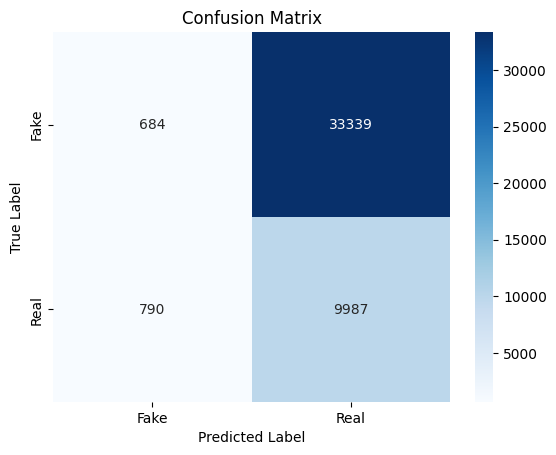

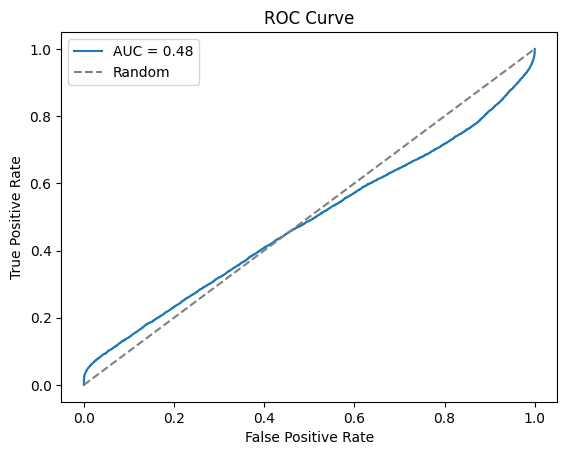

Found 44800 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1400/1400 [==============================] - 270s 191ms/step
[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.75      0.03      0.05     34023
        Real       0.24      0.97      0.39     10777

    accuracy                           0.25     44800
   macro avg       0.50      0.50      0.22     44800
weighted avg       0.63      0.25      0.13     44800

Confusion Matrix:
[[  933 33090]
 [  303 10474]]


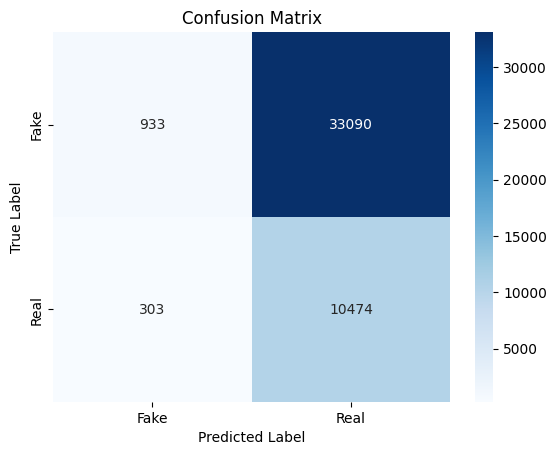

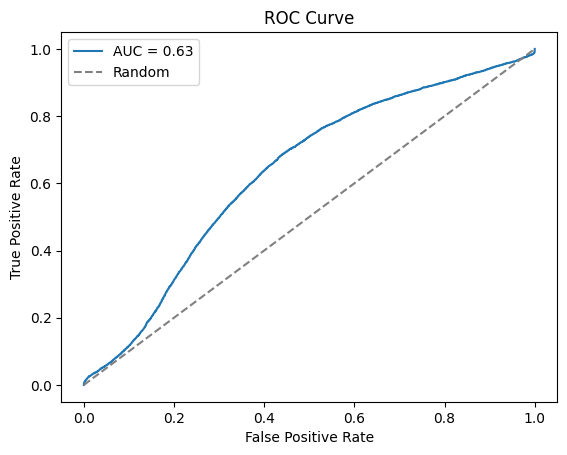

Found 44800 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1400/1400 [==============================] - 378s 264ms/step
[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.96      0.74      0.84     34023
        Real       0.53      0.91      0.67     10777

    accuracy                           0.78     44800
   macro avg       0.75      0.83      0.75     44800
weighted avg       0.86      0.78      0.80     44800

Confusion Matrix:
[[25238  8785]
 [  965  9812]]


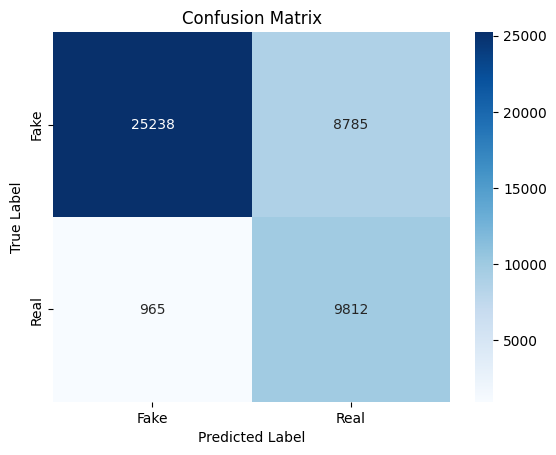

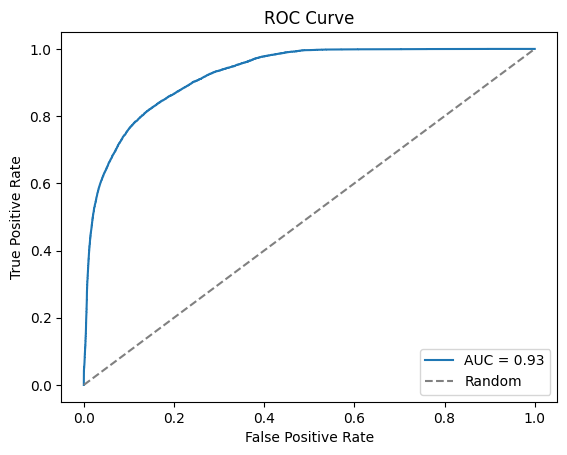

Found 44800 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1400/1400 [==============================] - 416s 295ms/step
[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.60      0.74     34023
        Real       0.43      0.95      0.59     10777

    accuracy                           0.69     44800
   macro avg       0.70      0.78      0.67     44800
weighted avg       0.84      0.69      0.71     44800

Confusion Matrix:
[[20507 13516]
 [  548 10229]]


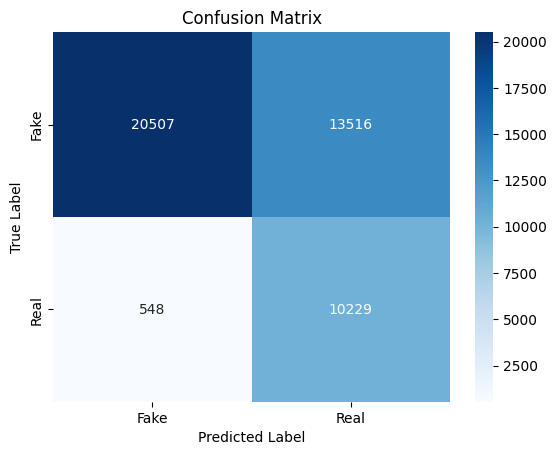

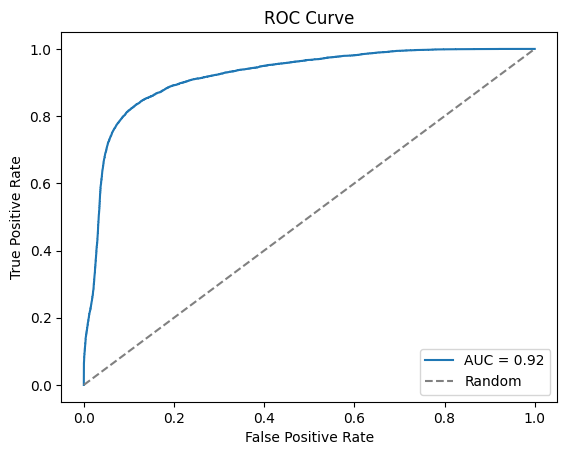

In [5]:
mean, preds, metrics = ens.soft_prediction('../DeepfakeTIMIT/data')

In [10]:
mean.shape

(7510, 1)

In [11]:
preds.shape

(5, 7510, 1)

In [14]:
metrics

array([{'accuracy': 0.9171770972037283, 'precision': 0.8817442719881744, 'recall': 0.9618382155334587, 'f1_score': 0.920051413881748, 'auc': 0.9793809702040639},
       {'accuracy': 0.8322237017310253, 'precision': 0.7750950145316342, 'recall': 0.9317387798978769, 'f1_score': 0.8462289480107396, 'auc': 0.9270414527576645},
       {'accuracy': 0.951797603195739, 'precision': 0.927027714213069, 'recall': 0.9798441279226014, 'f1_score': 0.9527044682518945, 'auc': 0.9870176820566244},
       {'accuracy': 0.9041278295605859, 'precision': 0.8824878919194494, 'recall': 0.930395055092717, 'f1_score': 0.9058084772370487, 'auc': 0.9610530816337112},
       {'accuracy': 0.9475366178428761, 'precision': 0.9279650115770517, 'recall': 0.9693630744423543, 'f1_score': 0.9482124079915878, 'auc': 0.9847833893626503}],
      dtype=object)

In [6]:
np.save('DeepfakeTIMIT_data_results/mean.npy', mean)
np.save('DeepfakeTIMIT_data_results/preds.npy', preds)
np.save('DeepfakeTIMIT_data_results/metrics.npy', metrics)

Found 17506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
548/548 [==============================] - 548s 1s/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.96      0.85      0.90      8037
        Real       0.88      0.97      0.92      9469

    accuracy                           0.91     17506
   macro avg       0.92      0.91      0.91     17506
weighted avg       0.92      0.91      0.91     17506

Confusion Matrix:
[[6801 1236]
 [ 312 9157]]


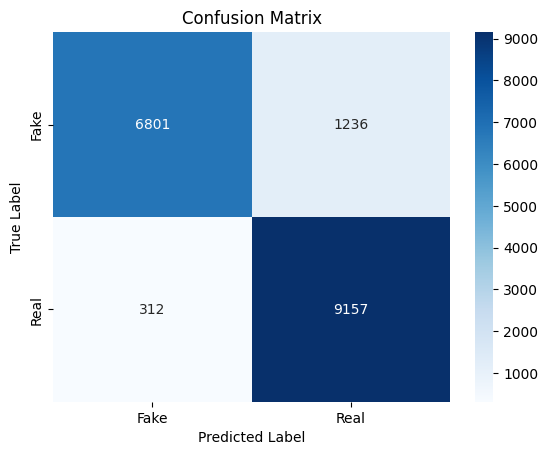

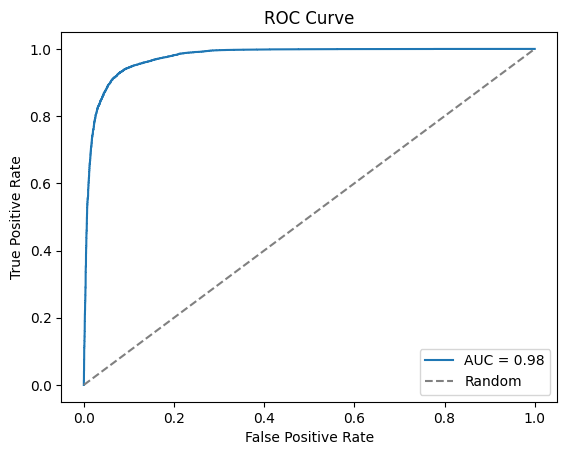

Found 17506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
548/548 [==============================] - 65s 118ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.89      0.66      0.76      8037
        Real       0.76      0.93      0.84      9469

    accuracy                           0.81     17506
   macro avg       0.83      0.79      0.80     17506
weighted avg       0.82      0.81      0.80     17506

Confusion Matrix:
[[5286 2751]
 [ 660 8809]]


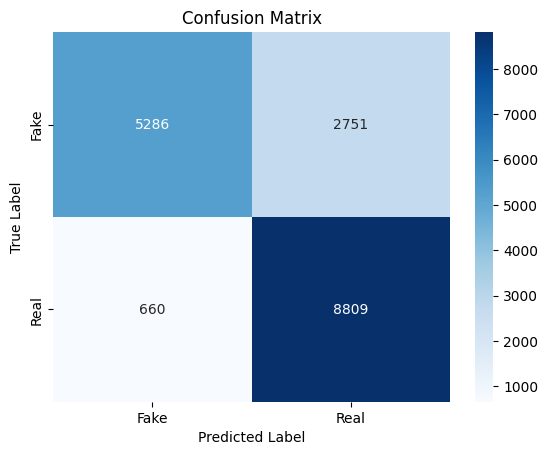

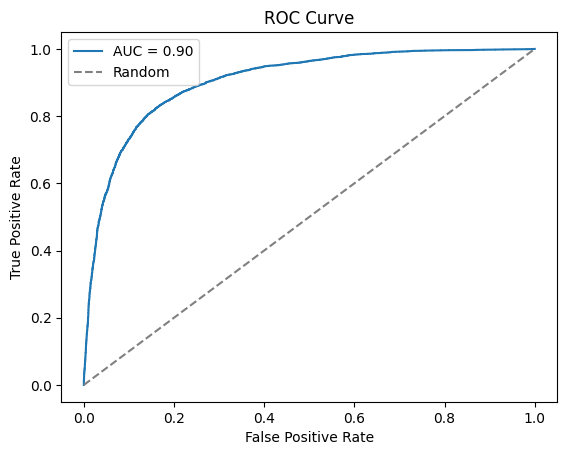

Found 17506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
548/548 [==============================] - 106s 193ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.91      0.94      8037
        Real       0.93      0.98      0.95      9469

    accuracy                           0.95     17506
   macro avg       0.95      0.94      0.95     17506
weighted avg       0.95      0.95      0.95     17506

Confusion Matrix:
[[7296  741]
 [ 191 9278]]


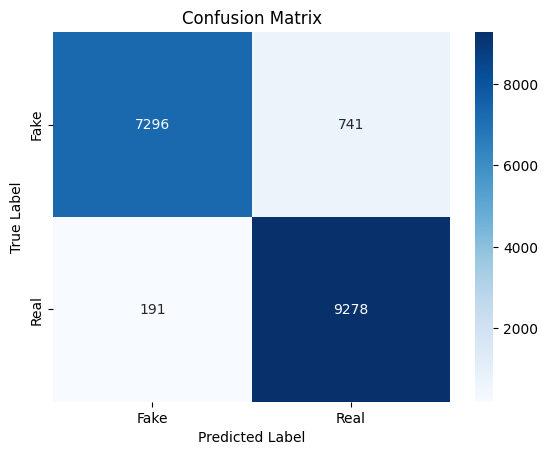

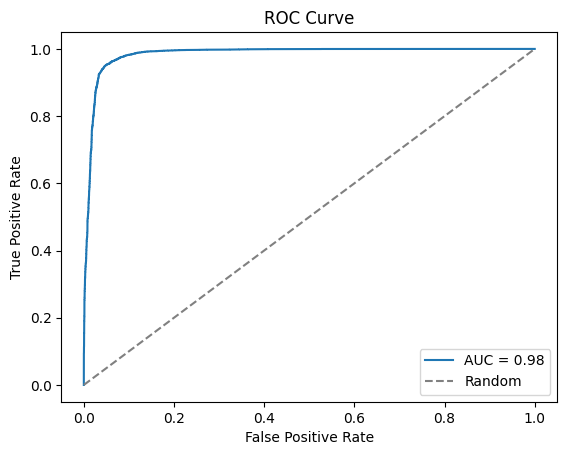

Found 17506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
548/548 [==============================] - 146s 267ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.91      0.85      0.88      8037
        Real       0.88      0.93      0.90      9469

    accuracy                           0.89     17506
   macro avg       0.89      0.89      0.89     17506
weighted avg       0.89      0.89      0.89     17506

Confusion Matrix:
[[6794 1243]
 [ 649 8820]]


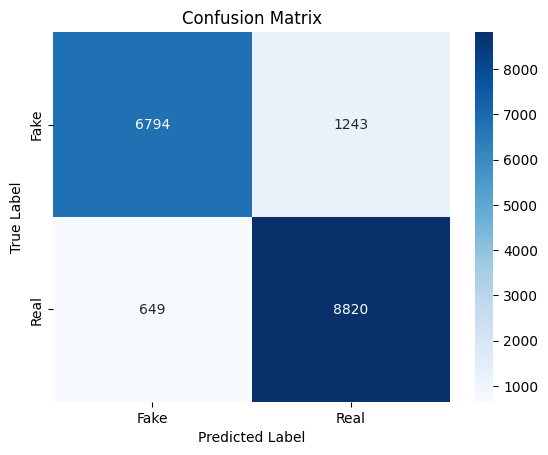

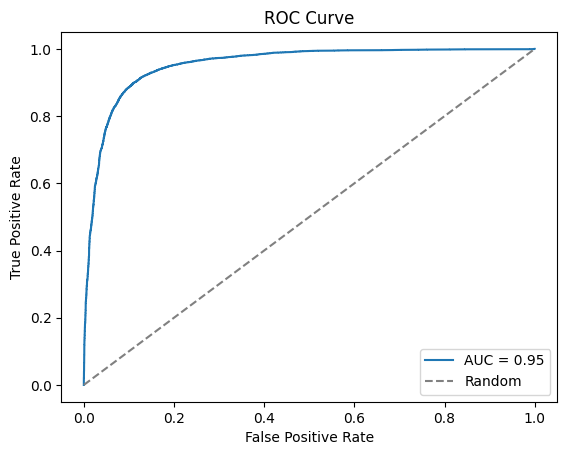

Found 17506 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
548/548 [==============================] - 154s 281ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.91      0.94      8037
        Real       0.93      0.98      0.95      9469

    accuracy                           0.95     17506
   macro avg       0.95      0.94      0.95     17506
weighted avg       0.95      0.95      0.95     17506

Confusion Matrix:
[[7343  694]
 [ 228 9241]]


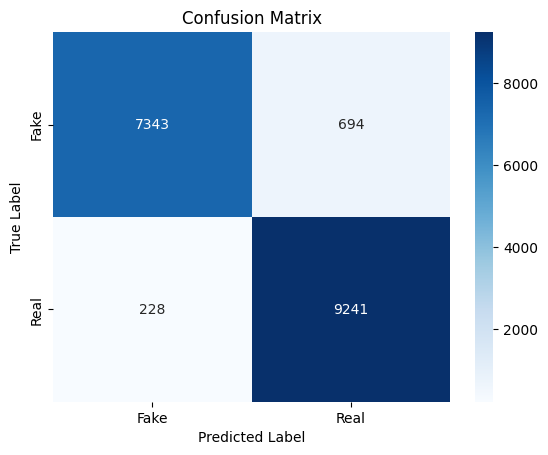

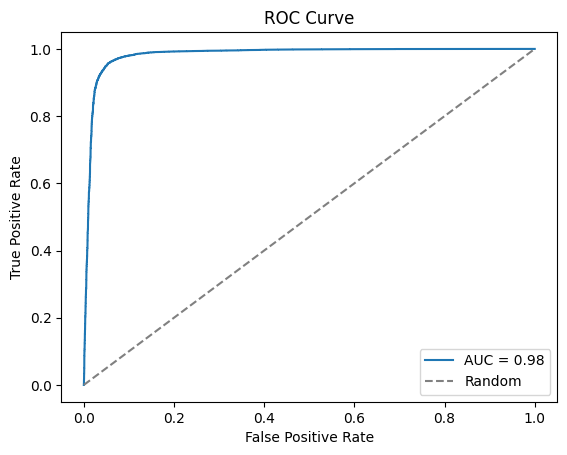

In [7]:
mean, preds, metrics = ens.soft_prediction('../data/test/')

In [8]:
np.save('data_test_results/mean.npy', mean)
np.save('data_test_results/preds.npy', preds)
np.save('data_test_results/metrics.npy', metrics)

Found 7510 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
235/235 [==============================] - 121s 518ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.96      0.87      0.91      3789
        Real       0.88      0.96      0.92      3721

    accuracy                           0.92      7510
   macro avg       0.92      0.92      0.92      7510
weighted avg       0.92      0.92      0.92      7510

Confusion Matrix:
[[3309  480]
 [ 142 3579]]


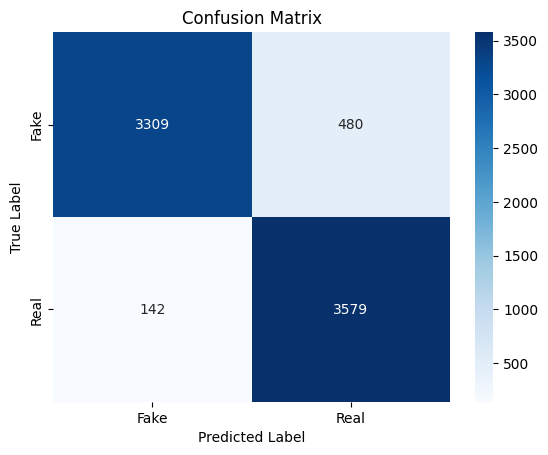

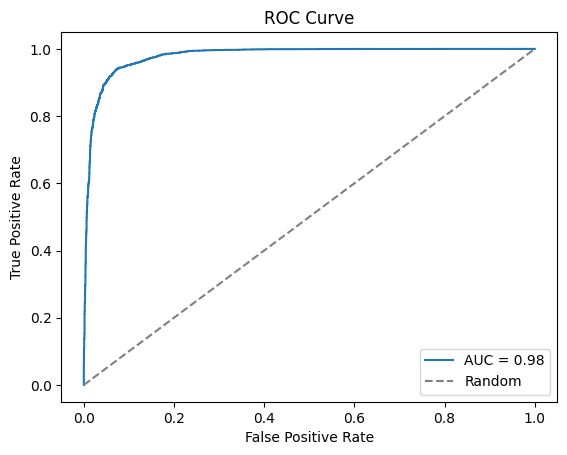

Found 7510 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
235/235 [==============================] - 30s 128ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.92      0.73      0.82      3789
        Real       0.78      0.93      0.85      3721

    accuracy                           0.83      7510
   macro avg       0.85      0.83      0.83      7510
weighted avg       0.85      0.83      0.83      7510

Confusion Matrix:
[[2783 1006]
 [ 254 3467]]


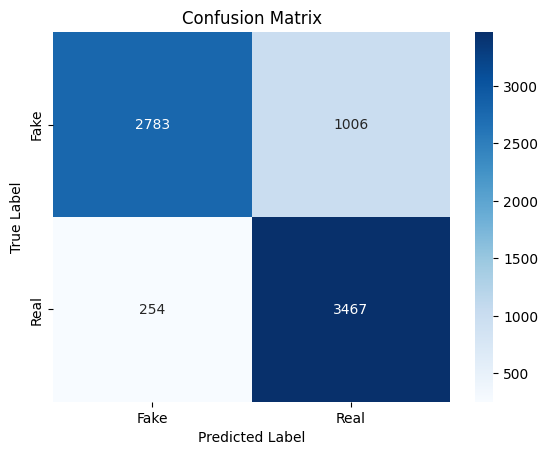

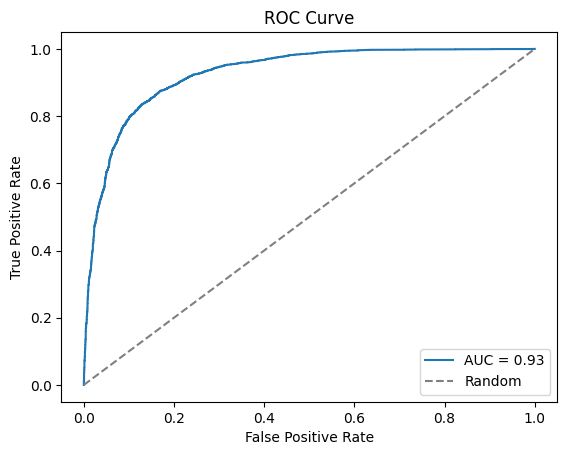

Found 7510 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
235/235 [==============================] - 48s 203ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.92      0.95      3789
        Real       0.93      0.98      0.95      3721

    accuracy                           0.95      7510
   macro avg       0.95      0.95      0.95      7510
weighted avg       0.95      0.95      0.95      7510

Confusion Matrix:
[[3502  287]
 [  75 3646]]


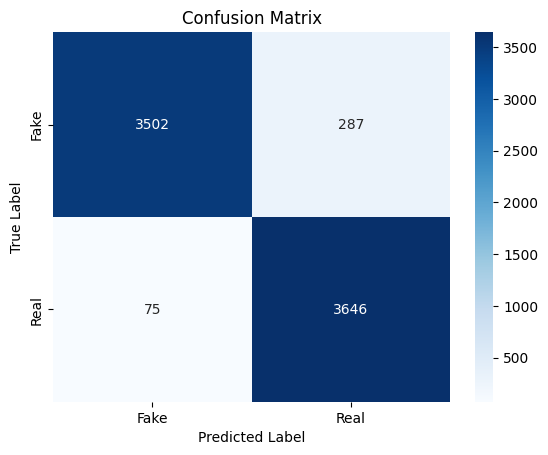

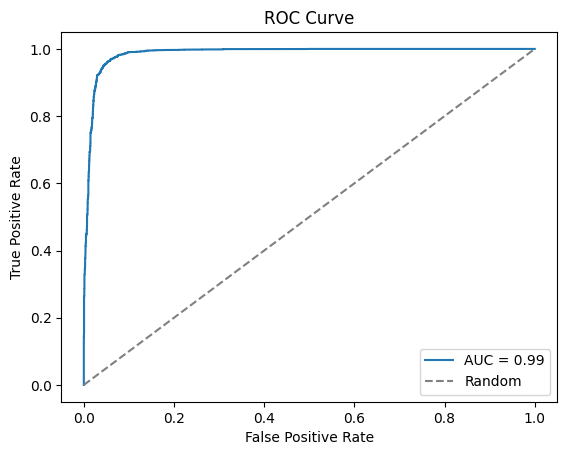

Found 7510 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
235/235 [==============================] - 70s 300ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.93      0.88      0.90      3789
        Real       0.88      0.93      0.91      3721

    accuracy                           0.90      7510
   macro avg       0.91      0.90      0.90      7510
weighted avg       0.91      0.90      0.90      7510

Confusion Matrix:
[[3328  461]
 [ 259 3462]]


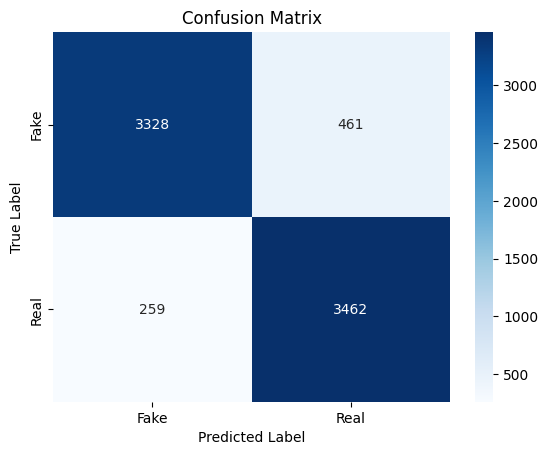

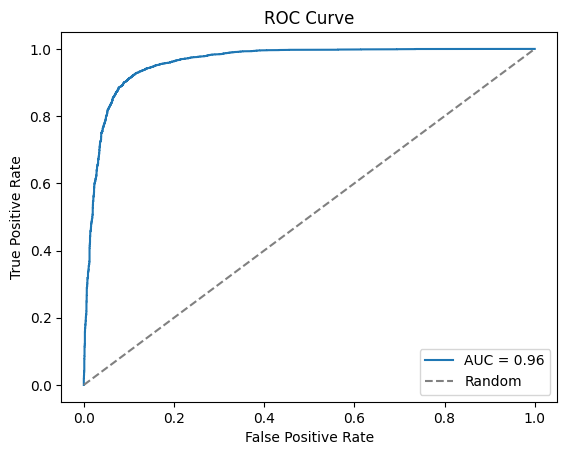

Found 7510 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
235/235 [==============================] - 70s 299ms/step
[[0]
 [0]
 [0]
 ...
 [1]
 [1]
 [1]]
Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.93      0.95      3789
        Real       0.93      0.97      0.95      3721

    accuracy                           0.95      7510
   macro avg       0.95      0.95      0.95      7510
weighted avg       0.95      0.95      0.95      7510

Confusion Matrix:
[[3509  280]
 [ 114 3607]]


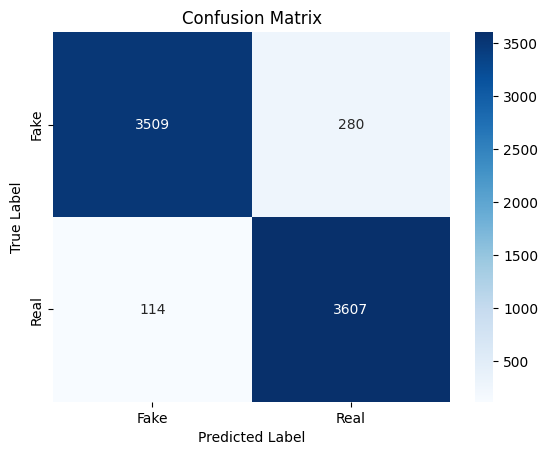

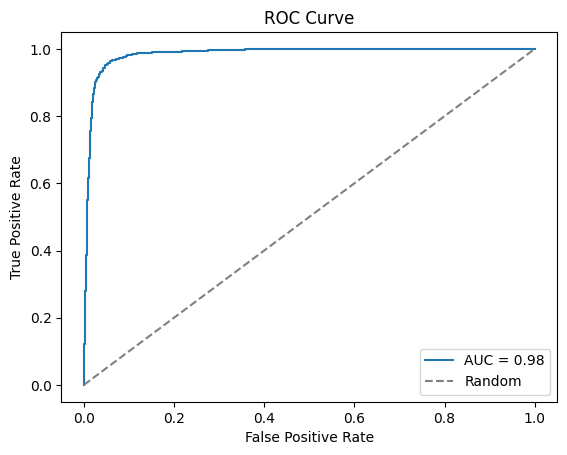

In [9]:
mean, preds, metrics = ens.soft_prediction('../test/')

In [10]:
np.save('test_results/mean.npy', mean)
np.save('test_results/preds.npy', preds)
np.save('test_results/metrics.npy', metrics)

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 908s 537ms/step


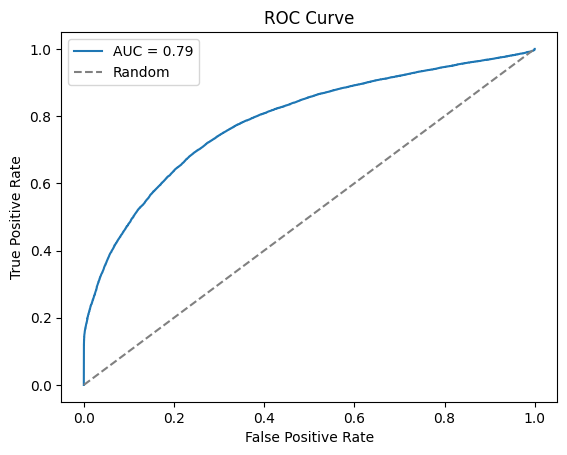

optimal threshold =  0.9146064
Classification Report:
              precision    recall  f1-score   support

        Fake       0.81      0.76      0.78     34023
        Real       0.62      0.69      0.65     19787

    accuracy                           0.73     53810
   macro avg       0.72      0.72      0.72     53810
weighted avg       0.74      0.73      0.73     53810

Confusion Matrix:
[[25729  8294]
 [ 6120 13667]]


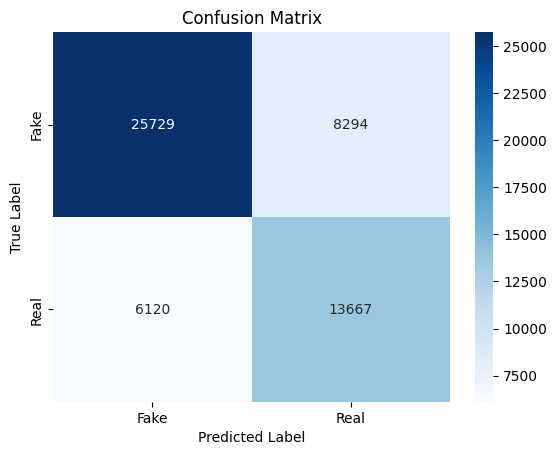

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 197s 116ms/step


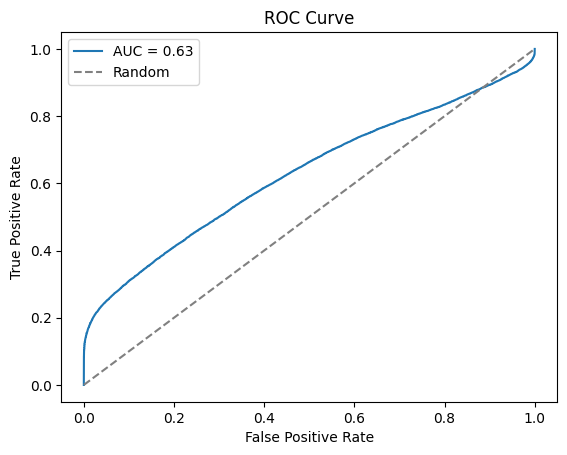

optimal threshold =  0.9804112
Classification Report:
              precision    recall  f1-score   support

        Fake       0.70      0.84      0.76     34023
        Real       0.57      0.37      0.45     19787

    accuracy                           0.67     53810
   macro avg       0.64      0.61      0.61     53810
weighted avg       0.65      0.67      0.65     53810

Confusion Matrix:
[[28514  5509]
 [12376  7411]]


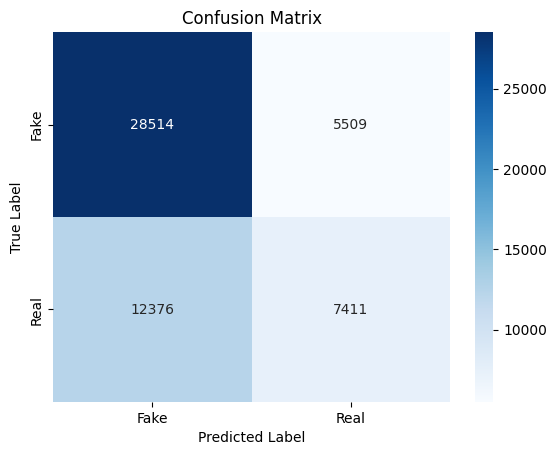

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 319s 188ms/step


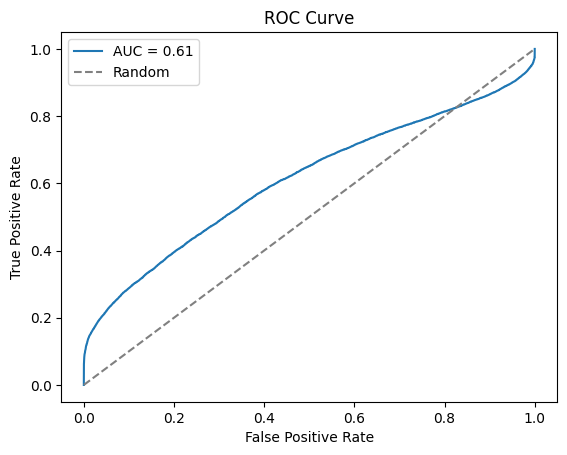

optimal threshold =  0.9960711
Classification Report:
              precision    recall  f1-score   support

        Fake       0.69      0.81      0.75     34023
        Real       0.54      0.38      0.45     19787

    accuracy                           0.65     53810
   macro avg       0.62      0.60      0.60     53810
weighted avg       0.64      0.65      0.64     53810

Confusion Matrix:
[[27621  6402]
 [12192  7595]]


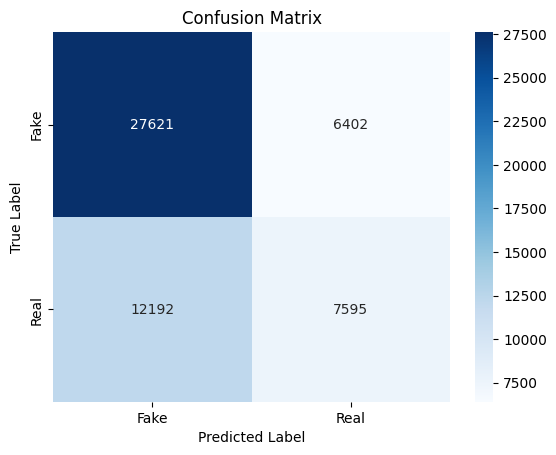

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 452s 263ms/step


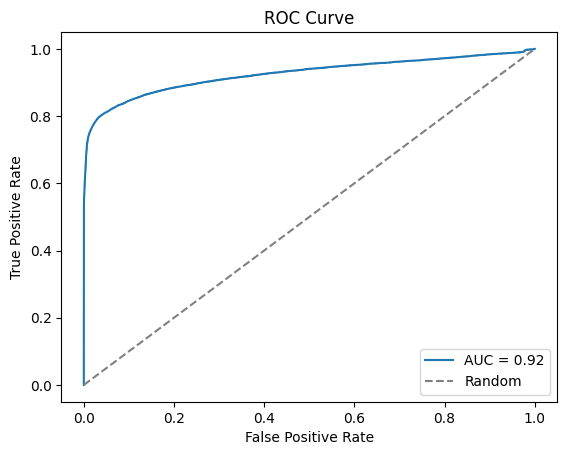

optimal threshold =  0.92408305
Classification Report:
              precision    recall  f1-score   support

        Fake       0.89      0.96      0.93     34023
        Real       0.92      0.80      0.86     19787

    accuracy                           0.90     53810
   macro avg       0.91      0.88      0.89     53810
weighted avg       0.90      0.90      0.90     53810

Confusion Matrix:
[[32720  1303]
 [ 3918 15869]]


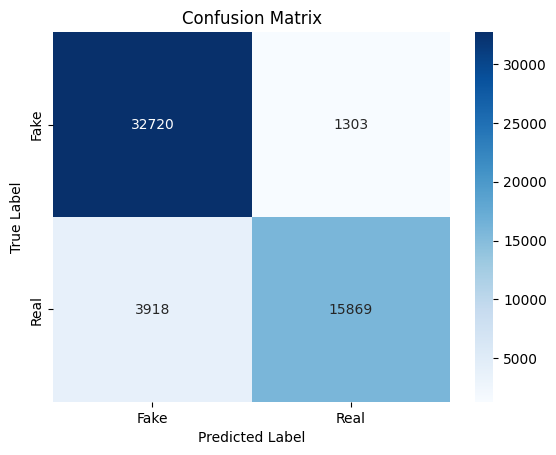

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 563s 333ms/step


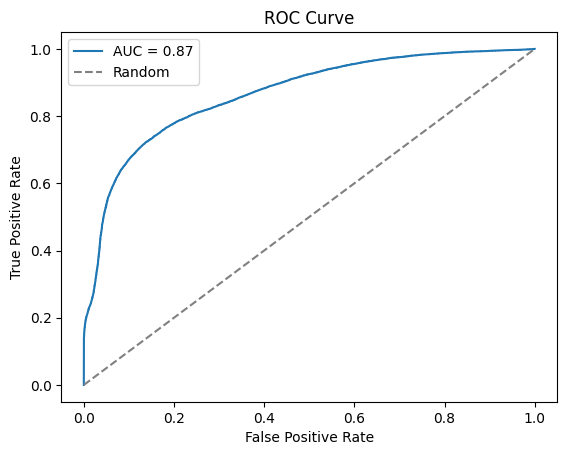

optimal threshold =  0.84067935
Classification Report:
              precision    recall  f1-score   support

        Fake       0.84      0.86      0.85     34023
        Real       0.75      0.72      0.74     19787

    accuracy                           0.81     53810
   macro avg       0.80      0.79      0.79     53810
weighted avg       0.81      0.81      0.81     53810

Confusion Matrix:
[[29341  4682]
 [ 5489 14298]]


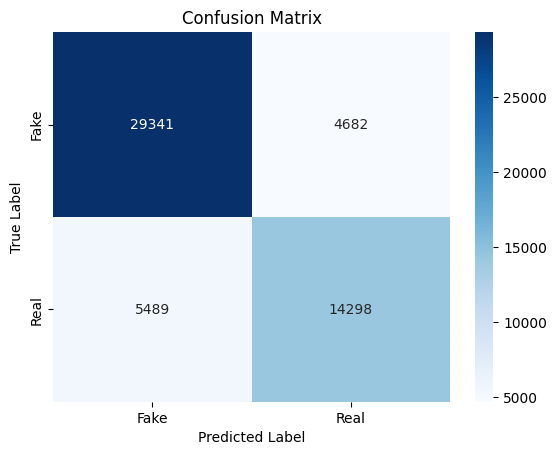

In [5]:
mean, preds, metrics = ens.soft_prediction('../DeepfakeTIMIT/data')

In [ ]:
np.save('balanced_DeepfakeTIMIT_data_results/mean.npy', mean)
np.save('balanced_DeepfakeTIMIT_data_results/preds.npy', preds)
np.save('balanced_DeepfakeTIMIT_data_results/metrics.npy', metrics)

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 251s 146ms/step


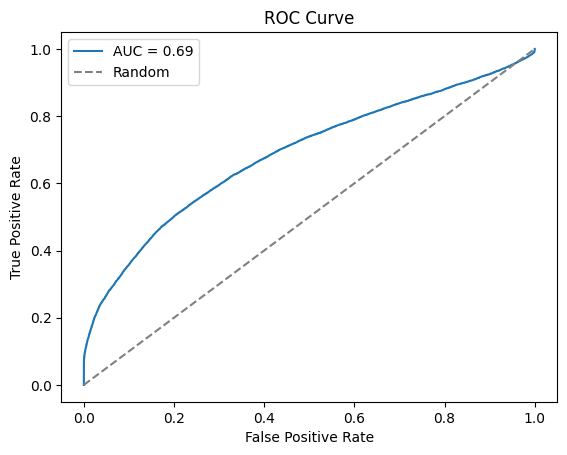

optimal threshold =  0.97402906
Classification Report:
              precision    recall  f1-score   support

        Fake       0.73      0.80      0.76     34023
        Real       0.59      0.51      0.55     19787

    accuracy                           0.69     53810
   macro avg       0.66      0.65      0.65     53810
weighted avg       0.68      0.69      0.68     53810

Confusion Matrix:
[[27105  6918]
 [ 9779 10008]]


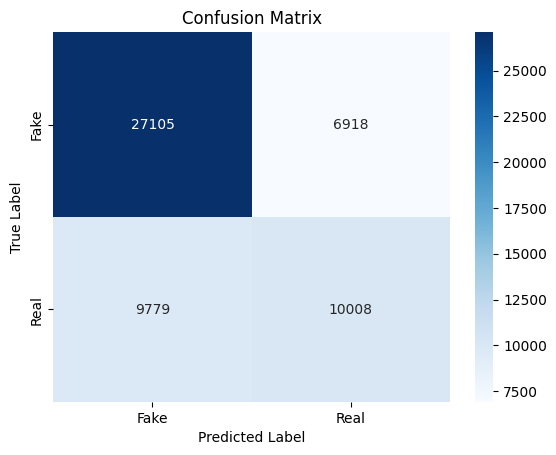

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 170s 100ms/step


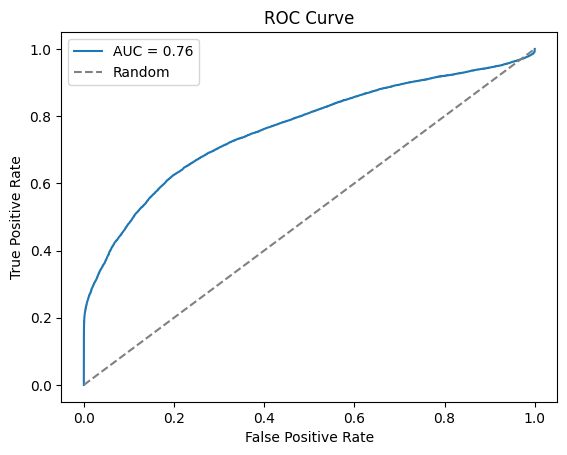

optimal threshold =  0.97537714
Classification Report:
              precision    recall  f1-score   support

        Fake       0.79      0.80      0.79     34023
        Real       0.65      0.62      0.64     19787

    accuracy                           0.74     53810
   macro avg       0.72      0.71      0.71     53810
weighted avg       0.73      0.74      0.74     53810

Confusion Matrix:
[[27288  6735]
 [ 7446 12341]]


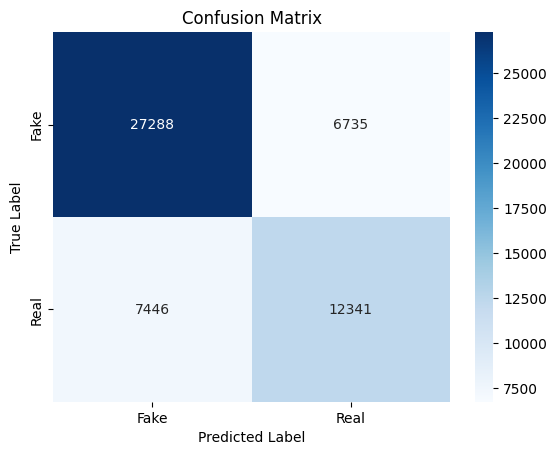

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 314s 185ms/step


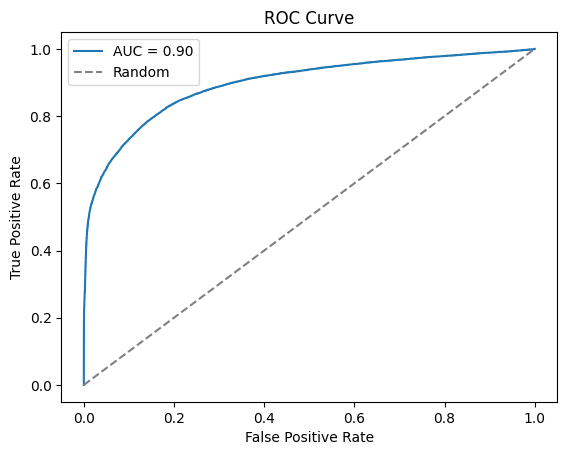

optimal threshold =  0.97118604
Classification Report:
              precision    recall  f1-score   support

        Fake       0.87      0.86      0.87     34023
        Real       0.76      0.79      0.77     19787

    accuracy                           0.83     53810
   macro avg       0.82      0.82      0.82     53810
weighted avg       0.83      0.83      0.83     53810

Confusion Matrix:
[[29166  4857]
 [ 4232 15555]]


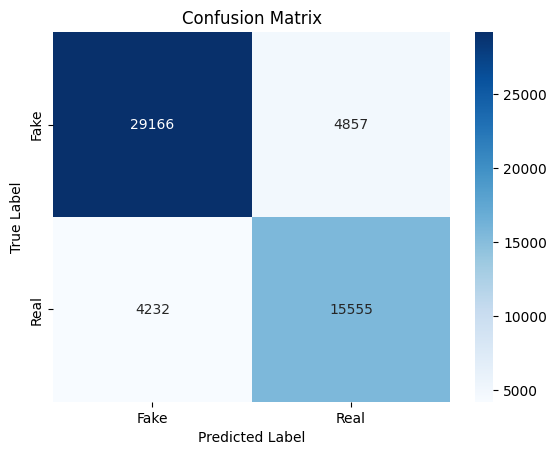

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 443s 258ms/step


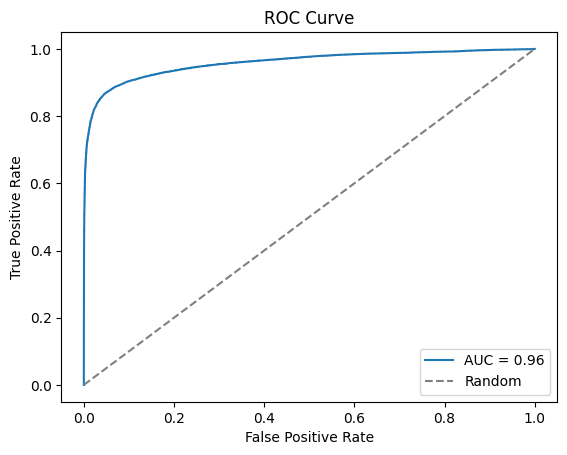

optimal threshold =  0.20039353
Classification Report:
              precision    recall  f1-score   support

        Fake       0.93      0.95      0.94     34023
        Real       0.91      0.87      0.89     19787

    accuracy                           0.92     53810
   macro avg       0.92      0.91      0.91     53810
weighted avg       0.92      0.92      0.92     53810

Confusion Matrix:
[[32292  1731]
 [ 2544 17243]]


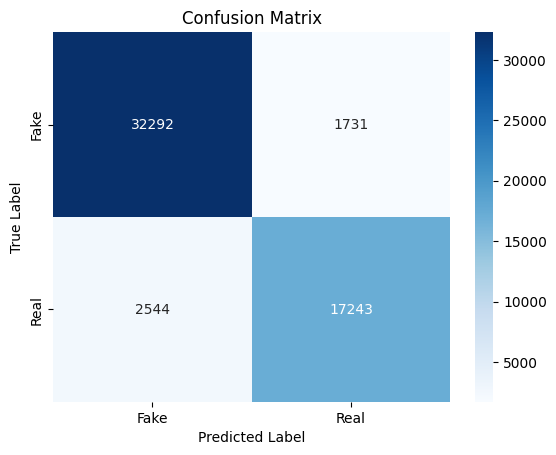

Found 53810 images belonging to 2 classes.
[0 0 0 ... 1 1 1]
1682/1682 [==============================] - 476s 282ms/step


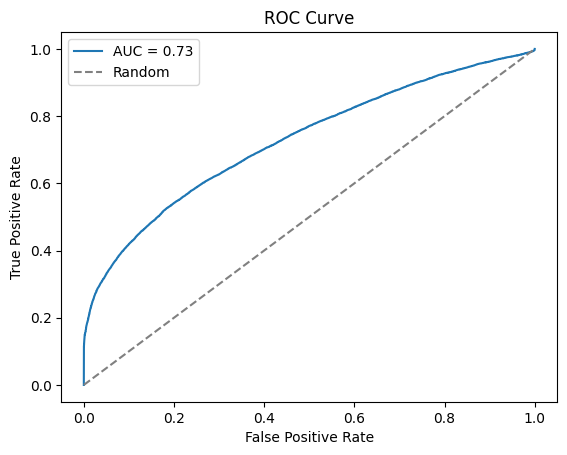

optimal threshold =  0.93454367
Classification Report:
              precision    recall  f1-score   support

        Fake       0.75      0.82      0.78     34023
        Real       0.62      0.53      0.57     19787

    accuracy                           0.71     53810
   macro avg       0.69      0.67      0.68     53810
weighted avg       0.70      0.71      0.70     53810

Confusion Matrix:
[[27777  6246]
 [ 9385 10402]]


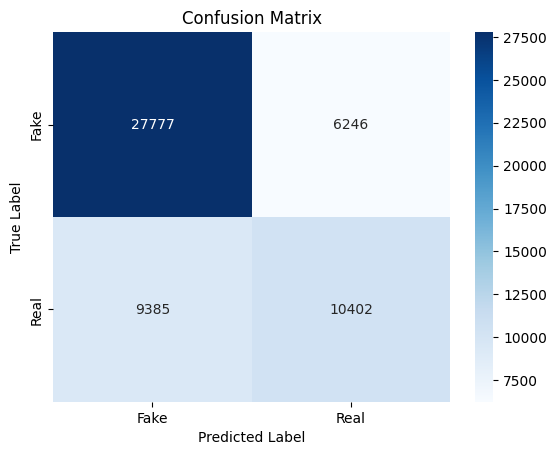

In [5]:
mean, preds, metrics = ens.soft_prediction('../DeepfakeTIMIT/data')

In [6]:
    np.save('balanced_DeepfakeTIMIT_data_results_v2/mean.npy', mean)
np.save('balanced_DeepfakeTIMIT_data_results_v2/preds.npy', preds)
np.save('balanced_DeepfakeTIMIT_data_results_v2/metrics.npy', metrics)

In [5]:
import numpy as np
from itertools import combinations
from sklearn.metrics import accuracy_score, roc_curve
import os
import pandas as pd
import json
import openpyxl
test_datagen = ImageDataGenerator(
    rescale=1./255
    #preprocessing_function=preprocessing_function
)  

test_generator = test_datagen.flow_from_directory(
    '../DeepfakeTIMIT/data')

true_labels = test_generator.classes
mean = np.load('balanced_DeepfakeTIMIT_data_results_v2/mean.npy')
preds = np.load('balanced_DeepfakeTIMIT_data_results_v2/preds.npy')

# Названия моделей (в том же порядке, в котором они сохранены в preds)
model_names = ['InceptionV3', 'MobileNetV2', 'ResNetV2', 'VGG16', 'Xception']

# Проверка соответствия размерностей
print(f"Количество моделей в preds: {preds.shape[0]}")
print(f"Названия моделей: {model_names}")
print(f"Размер preds: {preds.shape}")  # должно быть (5, n_samples, n_classes)

# Вычисляем оптимальные пороги для каждой модели по методу Йудена
optimal_thresholds = []
print("\nВычисление оптимальных порогов для каждой модели:")
for i, name in enumerate(model_names):
    # Предполагаем бинарную классификацию (берем вероятность класса 1)
    predictions = preds[i]
    
    # Если predictions имеет форму (n_samples, 2) для бинарной классификации
    if len(predictions.shape) > 1 and predictions.shape[1] > 1:
        prob_class1 = predictions[:, 1]  # вероятность класса 1
    else:
        prob_class1 = predictions.flatten()
    
    fpr, tpr, thresholds = roc_curve(true_labels, prob_class1)
    youden_index = tpr - fpr
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]
    optimal_thresholds.append(optimal_threshold)
    
    print(f"{name}: оптимальный порог = {optimal_threshold:.4f}")

optimal_thresholds = np.array(optimal_thresholds)

# Создаем словарь для быстрого доступа к данным по имени модели
model_data = {
    name: {
        'predictions': preds[i],
        'threshold': optimal_thresholds[i],
        'index': i
    }
    for i, name in enumerate(model_names)
}

# Список всех возможных комбинаций моделей (от 1 до 5 моделей)
all_combinations = []
for r in range(1, len(model_names) + 1):
    for combo in combinations(model_names, r):
        all_combinations.append(combo)

print(f"\nВсего комбинаций для анализа: {len(all_combinations)}")

# Функция для голосования с порогами
def voting_with_thresholds(model_names_combo, model_data_dict, true_labels):
    """Голосование с применением порогов к каждой модели"""
    n_samples = true_labels.shape[0]
    n_models_in_combo = len(model_names_combo)
    
    # Бинаризируем предсказания с учетом порогов
    binary_predictions = []
    thresholds_list = []
    
    for name in model_names_combo:
        data = model_data_dict[name]
        pred = data['predictions']
        threshold = data['threshold']
        
        # Берем вероятность класса 1
        if len(pred.shape) > 1 and pred.shape[1] > 1:
            prob_class1 = pred[:, 1]
        else:
            prob_class1 = pred.flatten()
        
        # Применяем порог
        binary_pred = (prob_class1 >= threshold).astype(int)
        binary_predictions.append(binary_pred)
        thresholds_list.append(threshold)
    
    # Голосование большинством
    stacked = np.stack(binary_predictions, axis=1)
    final_predictions = []
    
    for sample in stacked:
        unique, counts = np.unique(sample, return_counts=True)
        # Если голоса равны, выбираем класс с меньшим индексом (0 или 1)
        # В бинарной классификации обычно выбирают 1 при равенстве
        if len(unique) > 1 and counts[0] == counts[1]:
            final_predictions.append(1)
        else:
            final_predictions.append(unique[np.argmax(counts)])
    
    final_predictions = np.array(final_predictions)
    
    # Вычисляем accuracy
    acc = accuracy_score(true_labels, final_predictions)
    
    return acc, final_predictions, thresholds_list

# Вычисляем accuracy для всех комбинаций
results = []
print("\nВычисление accuracy для всех комбинаций...")

for combo in all_combinations:
    acc, final_preds, thresholds = voting_with_thresholds(combo, model_data, true_labels)
    
    results.append({
        'combination': list(combo),
        'combination_str': '+'.join(combo),
        'n_models': len(combo),
        'accuracy': acc,
        'thresholds': thresholds,
        'thresholds_str': ', '.join([f'{t:.4f}' for t in thresholds])
    })

# Создаем DataFrame для удобного анализа
df_results = pd.DataFrame(results)

# Сортируем по accuracy
df_results_sorted = df_results.sort_values('accuracy', ascending=False).reset_index(drop=True)

# Сохраняем в CSV
csv_path = 'balanced_DeepfakeTIMIT_data_results_v2/ensemble_combinations_results.csv'
df_results_sorted.to_csv(csv_path, index=False, encoding='utf-8')

# Сохраняем в Excel для удобства просмотра
excel_path = 'balanced_DeepfakeTIMIT_data_results_v2/ensemble_combinations_results.xlsx'
df_results_sorted.to_excel(excel_path, index=False)

# Сохраняем в JSON для структурированного хранения
json_path = 'balanced_DeepfakeTIMIT_data_results_v2/ensemble_combinations_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    # Конвертируем в сериализуемый формат
    serializable_results = []
    for _, row in df_results_sorted.iterrows():
        serializable_results.append({
            'combination': row['combination'],
            'combination_str': row['combination_str'],
            'n_models': int(row['n_models']),
            'accuracy': float(row['accuracy']),
            'thresholds': [float(t) for t in row['thresholds']]
        })
    json.dump(serializable_results, f, indent=2, ensure_ascii=False)

# Выводим статистику
print(f"\nСтатистика по комбинациям:")
print(f"Лучшая accuracy: {df_results_sorted['accuracy'].iloc[0]:.4f}")
print(f"Худшая accuracy: {df_results_sorted['accuracy'].iloc[-1]:.4f}")
print(f"Средняя accuracy: {df_results_sorted['accuracy'].mean():.4f}")
print(f"Медианная accuracy: {df_results_sorted['accuracy'].median():.4f}")

# Анализ по количеству моделей
print(f"\nАнализ по количеству моделей в ансамбле:")
for n in range(1, 6):
    subset = df_results_sorted[df_results_sorted['n_models'] == n]
    if len(subset) > 0:
        print(f"  {n} модель(и): {len(subset)} комбинаций")
        print(f"    Лучшая accuracy: {subset['accuracy'].iloc[0]:.4f}")
        print(f"    Средняя accuracy: {subset['accuracy'].mean():.4f}")

# Топ-20 комбинаций
print(f"\nТоп-20 комбинаций моделей:")
print("=" * 80)
print(f"{'№':<3} {'Комбинация':<40} {'Моделей':<8} {'Accuracy':<10}")
print("-" * 80)
for i in range(min(20, len(df_results_sorted))):
    row = df_results_sorted.iloc[i]
    combo_str = '+'.join(row['combination'][:3])
    if len(row['combination']) > 3:
        combo_str += f"+...({len(row['combination'])} моделей)"
    
    print(f"{i+1:<3} {combo_str:<40} {row['n_models']:<8} {row['accuracy']:.4f}")
print("=" * 80)

# Лучшие комбинации для каждого количества моделей
print(f"\nЛучшие комбинации для каждого количества моделей:")
print("=" * 80)
print(f"{'Моделей':<8} {'Комбинация':<40} {'Accuracy':<10}")
print("-" * 80)
for n in range(1, 6):
    subset = df_results_sorted[df_results_sorted['n_models'] == n]
    if len(subset) > 0:
        best_row = subset.iloc[0]
        combo_str = '+'.join(best_row['combination'])
        print(f"{n:<8} {combo_str:<40} {best_row['accuracy']:.4f}")
print("=" * 80)

print(f"\nРезультаты сохранены в:")
print(f"  CSV: {csv_path}")
print(f"  Excel: {excel_path}")
print(f"  JSON: {json_path}")

# Дополнительно: сохраняем сводную статистику
summary_stats = {
    'total_combinations': len(all_combinations),
    'best_accuracy': float(df_results_sorted['accuracy'].iloc[0]),
    'best_combination': df_results_sorted['combination_str'].iloc[0],
    'models_in_best': int(df_results_sorted['n_models'].iloc[0]),
    'worst_accuracy': float(df_results_sorted['accuracy'].iloc[-1]),
    'mean_accuracy': float(df_results_sorted['accuracy'].mean()),
    'median_accuracy': float(df_results_sorted['accuracy'].median()),
    'model_thresholds': {name: float(model_data[name]['threshold']) for name in model_names},
    'individual_accuracies': {}  # можно добавить accuracy каждой модели по отдельности
}

# Вычисляем accuracy для каждой модели по отдельности
print(f"\nAccuracy отдельных моделей:")
print("-" * 40)
for name in model_names:
    data = model_data[name]
    pred = data['predictions']
    
    if len(pred.shape) > 1 and pred.shape[1] > 1:
        prob_class1 = pred[:, 1]
    else:
        prob_class1 = pred.flatten()
    
    binary_pred = (prob_class1 >= data['threshold']).astype(int)
    acc = accuracy_score(true_labels, binary_pred)
    summary_stats['individual_accuracies'][name] = float(acc)
    
    print(f"{name:<15} Accuracy: {acc:.4f}, Порог: {data['threshold']:.4f}")

# Сохраняем сводную статистику
summary_path = 'balanced_DeepfakeTIMIT_data_results_v2/ensemble_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary_stats, f, indent=2, ensure_ascii=False)

print(f"\nСводная статистика сохранена в: {summary_path}")

Found 53810 images belonging to 2 classes.
Количество моделей в preds: 5
Названия моделей: ['InceptionV3', 'MobileNetV2', 'ResNetV2', 'VGG16', 'Xception']
Размер preds: (5, 53810, 1)

Вычисление оптимальных порогов для каждой модели:
InceptionV3: оптимальный порог = 0.9740
MobileNetV2: оптимальный порог = 0.9754
ResNetV2: оптимальный порог = 0.9712
VGG16: оптимальный порог = 0.2004
Xception: оптимальный порог = 0.9345

Всего комбинаций для анализа: 31

Вычисление accuracy для всех комбинаций...

Статистика по комбинациям:
Лучшая accuracy: 0.9206
Худшая accuracy: 0.6810
Средняя accuracy: 0.8101
Медианная accuracy: 0.8307

Анализ по количеству моделей в ансамбле:
  1 модель(и): 5 комбинаций
    Лучшая accuracy: 0.9206
    Средняя accuracy: 0.7775
  2 модель(и): 10 комбинаций
    Лучшая accuracy: 0.8683
    Средняя accuracy: 0.7774
  3 модель(и): 10 комбинаций
    Лучшая accuracy: 0.8937
    Средняя accuracy: 0.8361
  4 модель(и): 5 комбинаций
    Лучшая accuracy: 0.8743
    Средняя accur

In [7]:
image = Image.open('../test/fake/120.png')
im_arr = np.array(image)

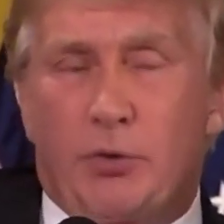

In [8]:
image

In [9]:
im_arr = np.expand_dims(im_arr, axis=0)
im_arr.shape

(1, 224, 224, 3)

In [10]:
preds, avg = ens.soft_prediction(im_arr)

1/1 [==============================] - 2s 2s/step


In [11]:
preds

array([[0.13019153]], dtype=float32)

In [12]:
avg

[array([[0.1801616]], dtype=float32),
 array([[0.3699266]], dtype=float32),
 array([[0.05890882]], dtype=float32),
 array([[0.03887806]], dtype=float32),
 array([[0.00308266]], dtype=float32)]

In [13]:
import cv2
import numpy as np

def from_video2array(filename : str):
    cap = cv2.VideoCapture(filename)
    frames = []
        
    while True:
        # Читаем кадр
        ret, frame = cap.read()
            
        # Если кадр прочитан успешно
        if ret:
            # Можно конвертировать из BGR в RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resize = cv2.resize(frame_rgb, (224, 224))
            frames.append(frame_resize)
        else:
            break
    cap.release()
    frames = np.array(frames)
    return frames

In [14]:
frames = from_video2array('../DeepfakeTIMIT/lower_quality/mrjo0/si1624-video-mstk0.avi')
frames.shape

(77, 224, 224, 3)

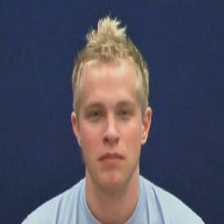

In [16]:
from PIL import Image
img = Image.fromarray(frames[0])
img

In [53]:
avg, preds = ens.soft_prediction(frames)

3/3 [==============================] - 2s 286ms/step


In [70]:
avg[0]

array([0.8016532], dtype=float32)

In [69]:
preds[:, 0]

array([[0.99217236],
       [0.9904246 ],
       [0.99997985],
       [0.26876855],
       [0.7569204 ]], dtype=float32)

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Normalize pixel values to [0, 1]
    validation_split=validation_split  # Split into training and validation
)